In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2026-08-06
Revised on 2026-08-06

@author:       Oscar Trevizo, Visiting Professor
@institution:  DeVry University
@context:      SIS150 -- Fundamentals of Programming
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Module 6.3: Data Visualization with Matplotlib
=================================================

Description:
    Live, in-class walkthrough notebook for SIS150 Module 6. Short,
    cell-by-cell demo run on the instructor's screen while students
    follow along and reproduce each cell themselves. Parallels zyBooks
    CEIS150 "Fundamentals of Programming" (Module 6, section 6.4,
    "Matplotlib") using original, non-duplicated examples. Continues
    the Beatles/music theme from Modules 4-5, and reuses the CSV built
    in Module 6.1.

    Topics covered:
        Line plots and scatter plots -- plt.plot(), plt.scatter()
        Labeling -- title(), xlabel(), ylabel(), annotate(), legend()
        Styling -- color, linestyle, and marker format strings
        Grid lines -- grid()
        Multiple plots in one figure -- subplot(), suptitle()
        Saving a figure to disk -- savefig()

Data:
    data/abbey_road_tracks.csv -- 17 rows, one per Abbey Road track
        (track_number, track_name, track_popularity, track_duration_min),
        built in Module 6.1. See Sources below.

Sources:
    Track metadata (track_popularity, track_duration_min) derived from:
    Warda Bilal, "Spotify Global Music Dataset (2009-2025)," Kaggle,
    https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025/data
    -- filtered to The Beatles' "Abbey Road" album, reduced to a small
    17-row CSV. The full Kaggle files are not included in this repo.

Revision History:
    2026-08-06  Original development -- live-coding demo for Module 6.3
"""


'\nCreated on 2026-08-06\nRevised on 2026-08-06\n\n@author:       Oscar Trevizo, Visiting Professor\n@institution:  DeVry University\n@context:      SIS150 -- Fundamentals of Programming\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nModule 6.3: Data Visualization with Matplotlib\n=================================================\n\nDescription:\n    Live, in-class walkthrough notebook for SIS150 Module 6. Short,\n    cell-by-cell demo run on the instructor\'s screen while students\n    follow along and reproduce each cell themselves. Parallels zyBooks\n    CEIS150 "Fundamentals of Programming" (Module 6, section 6.4,\n    "Matplotlib") using original, non-duplicated examples. Continues\n    the Beatles/music theme from Modules 4-5, and reuses the CSV built\n    in Module 6.1.\n\n    Topics covered:\n        Line plots and scatter plots -- plt.plot(), plt.scatter()\n        Labeling -- title(), xlabel(), ylabel(), annotate(), legend()\n        Styling -- color, linestyle, an

# SIS150 Module 6.3 - Data Visualization with Matplotlib

Author: Prof. Oscar Trevizo

Date: August 6, 2026

## Reference

https://matplotlib.org/stable/tutorials/pyplot.html

Matplotlib is the most common Python plotting package. The `pyplot`
interface (conventionally imported as `plt`) builds a figure one
instruction at a time -- each line of code adds something (a plot, a
label, a title) to the figure already in progress.


## Loading the data

`data/abbey_road_tracks.csv` (built in Module 6.1) holds all 17
tracks from the Beatles' *Abbey Road* album, in track order, with
each track's Spotify popularity score (0-100) and duration in
minutes. Reading it with pandas gives a DataFrame -- much sturdier
than the manual `split(",")` approach from 6.1 once real-world CSVs
get messier.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# pd.read_csv() returns a DataFrame -- a table with labeled columns
abbey_road_df = pd.read_csv("data/abbey_road_tracks.csv")
abbey_road_df.head()


,track_number,track_name,track_popularity,track_duration_min
0,1,Come Together,77,4.33
1,2,Something,75,3.03
2,3,Maxwell's Silver Hammer,58,3.46
3,4,Oh! Darling,68,3.45
4,5,Octopus's Garden,65,2.84


## A line plot

`plt.plot(x, y)` connects consecutive points with a line -- a natural
fit here, since track order (1 through 17) is meaningful.


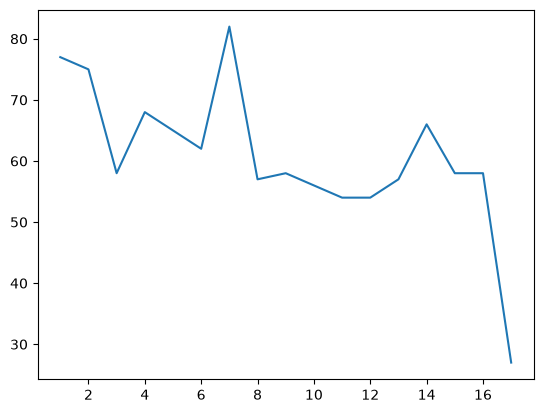

In [3]:
# track_number is numeric and runs 1-17 in a meaningful order, so a line
# connecting each point to the next actually means something here
plt.plot(abbey_road_df["track_number"], abbey_road_df["track_popularity"])
plt.show()


## A scatter plot

`plt.scatter(x, y)` plots each point on its own, with no connecting
line -- better when the x-axis isn't really a sequence, like duration
vs. popularity below (there's no reason a 3-minute track should
"come before" a 4-minute one).


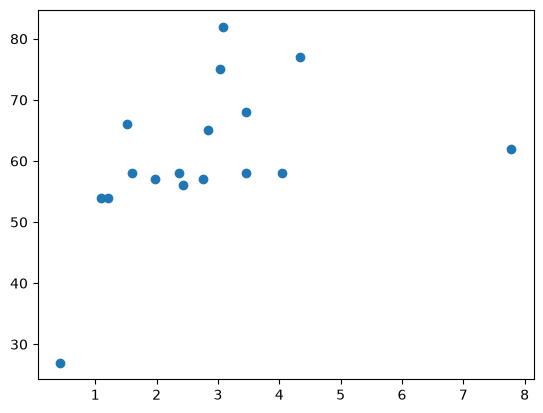

In [4]:
# duration isn't a sequence like track_number was -- scatter() plots each
# point on its own, with no line implying an order between them
plt.scatter(abbey_road_df["track_duration_min"], abbey_road_df["track_popularity"])
plt.show()


### Coloring by group

zyBooks' own scatter examples color points by category (two clusters,
in their Old Faithful data). Abbey Road doesn't come with machine-
learned clusters, but it does have a real, simple two-way split: the
original UK vinyl's **Side A** (tracks 1-6) and **Side B** (tracks
7-17, including the famous closing medley). Splitting the DataFrame
with a boolean condition, then calling `scatter()` once per group with
a different `label`, produces the same two-tone look -- and this is
also the first real use of `legend()` in this notebook.


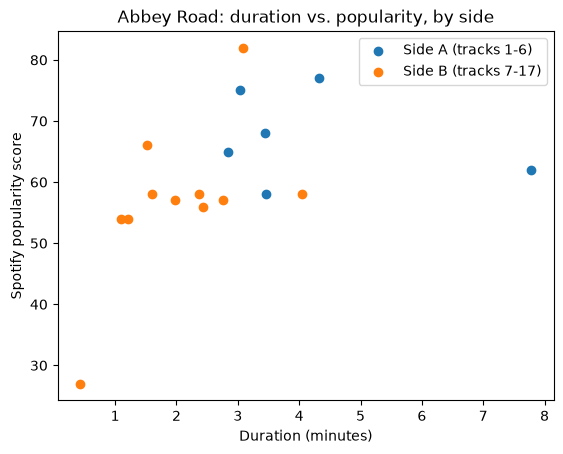

In [5]:
# track_number <= 6 is a boolean condition applied to a whole column --
# it returns a Series of True/False, one per row, used here to filter
side_a_df = abbey_road_df[abbey_road_df["track_number"] <= 6]
side_b_df = abbey_road_df[abbey_road_df["track_number"] > 6]

plt.scatter(side_a_df["track_duration_min"], side_a_df["track_popularity"], label="Side A (tracks 1-6)")
plt.scatter(side_b_df["track_duration_min"], side_b_df["track_popularity"], label="Side B (tracks 7-17)")
plt.title("Abbey Road: duration vs. popularity, by side")
plt.xlabel("Duration (minutes)")
plt.ylabel("Spotify popularity score")
plt.legend()  # uses each scatter() call's label= to build the legend
plt.show()


## Labeling a plot

`title()`, `xlabel()`, and `ylabel()` add text to a figure.
`annotate()` links a text string to a specific point -- useful for
calling out one data point, like the album's shortest, quietest
track: "Her Majesty" is a 23-second hidden bonus track, tacked onto
the end of the medley almost as an afterthought.


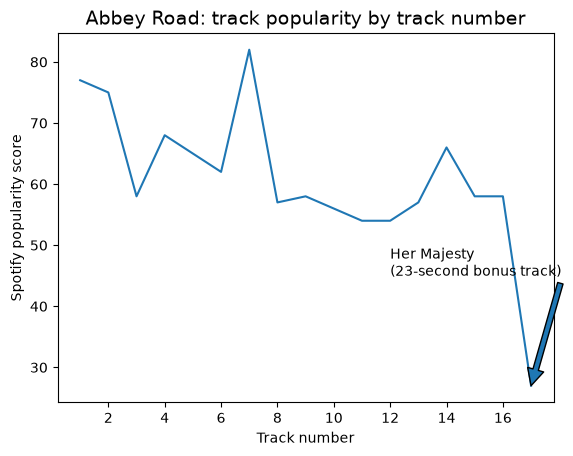

In [6]:
plt.plot(abbey_road_df["track_number"], abbey_road_df["track_popularity"])
plt.title("Abbey Road: track popularity by track number", fontsize=14)
plt.xlabel("Track number")
plt.ylabel("Spotify popularity score")
# xy is the data point being pointed AT; xytext is where the label text
# itself gets placed -- matplotlib draws the arrow connecting the two
plt.annotate(
    "Her Majesty\n(23-second bonus track)",
    xy=(17, 27),
    xytext=(12, 45),
    arrowprops=dict(),
)
plt.show()


## Styling a plot

A format string combines color, marker, and line style characters,
e.g. `'go--'` is green (`g`), circle markers (`o`), dashed line
(`--`). Style can also be set with the `color`, `marker`, and
`linestyle` keyword arguments -- same result, more readable.


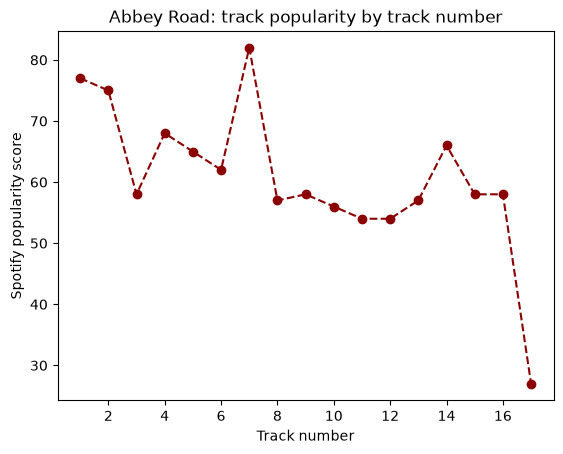

In [7]:
# same line plot as before, styled with explicit keywords instead of a
# packed format string like 'ro--'
plt.plot(
    abbey_road_df["track_number"],
    abbey_road_df["track_popularity"],
    color="darkred",
    marker="o",
    linestyle="--",
)
plt.title("Abbey Road: track popularity by track number")
plt.xlabel("Track number")
plt.ylabel("Spotify popularity score")
plt.show()


## Grid lines

`plt.grid()` adds grid lines, which make it easier to read a value off
a plot. The `axis` parameter can limit grid lines to just `'x'` or
`'y'`.


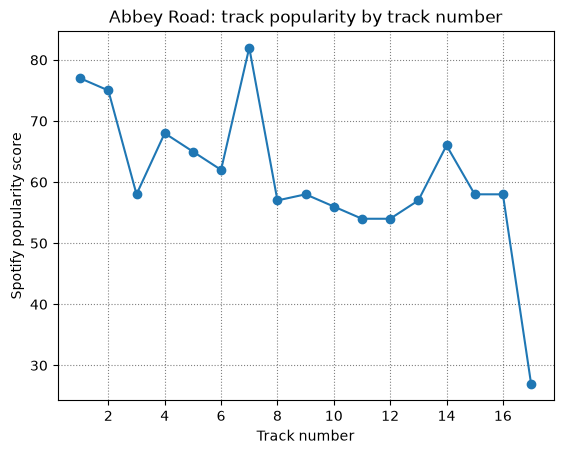

In [8]:
# grid() just adds reference lines behind whatever's already plotted
plt.plot(abbey_road_df["track_number"], abbey_road_df["track_popularity"], marker="o")
plt.title("Abbey Road: track popularity by track number")
plt.xlabel("Track number")
plt.ylabel("Spotify popularity score")
plt.grid(linestyle=":", color="gray")
plt.show()


## Multiple plots in one figure

`plt.subplot(nrows, ncols, index)` places a plot into a grid of
subplots within one figure. `plt.suptitle()` titles the whole figure,
as opposed to `plt.title()`, which titles just the current subplot.


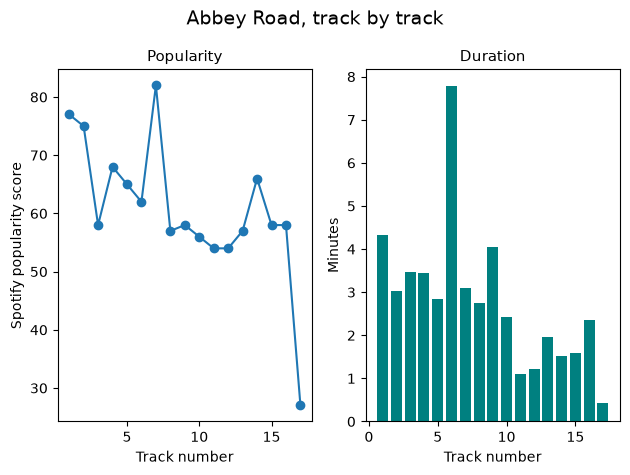

In [9]:
plt.suptitle("Abbey Road, track by track", fontsize=14)

# subplot(1, 2, 1): a 1-row, 2-column grid -- this is subplot #1 (left)
plt.subplot(1, 2, 1)
plt.plot(abbey_road_df["track_number"], abbey_road_df["track_popularity"], marker="o")
plt.title("Popularity", fontsize=11)
plt.xlabel("Track number")
plt.ylabel("Spotify popularity score")

# subplot(1, 2, 2): same 1x2 grid -- this is subplot #2 (right)
plt.subplot(1, 2, 2)
plt.bar(abbey_road_df["track_number"], abbey_road_df["track_duration_min"], color="teal")
plt.title("Duration", fontsize=11)
plt.xlabel("Track number")
plt.ylabel("Minutes")

plt.tight_layout()
plt.show()


## Saving a figure

`plt.savefig(fname)` writes the current figure to a file (PNG, by
default). It must be called *before* `plt.show()` -- once shown, the
figure is considered done.


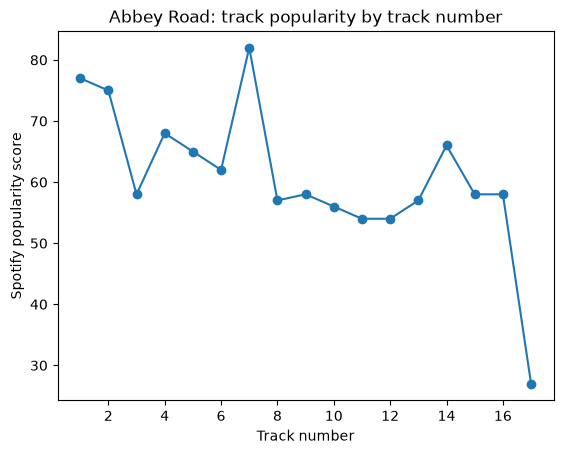

Saved data/abbey_road_popularity.png


In [10]:
# savefig() must come before show() -- once shown, matplotlib treats
# this figure as done and the next plot starts a new one
plt.plot(abbey_road_df["track_number"], abbey_road_df["track_popularity"], marker="o")
plt.title("Abbey Road: track popularity by track number")
plt.xlabel("Track number")
plt.ylabel("Spotify popularity score")
plt.savefig("data/abbey_road_popularity.png")
plt.show()

print("Saved data/abbey_road_popularity.png")


## Let's review

- `plt.plot()` connects points with a line; `plt.scatter()` plots
  points independently -- pick based on whether the x-axis is a
  meaningful sequence.
- `title()`, `xlabel()`, `ylabel()`, and `annotate()` add text;
  `legend()` labels multiple series in one figure.
- A format string like `'go--'` (or the `color`/`marker`/`linestyle`
  keywords) styles a plot.
- `plt.grid()` adds grid lines; `plt.subplot(nrows, ncols, index)`
  places multiple plots in one figure, titled overall with
  `plt.suptitle()`.
- `plt.savefig(fname)` writes the figure to disk -- call it before
  `plt.show()`.
